# 📊 Урок 2: Разведочный анализ данных (EDA) и визуализация

## Что такое EDA?

**EDA (Exploratory Data Analysis)** — это «знакомство» с данными перед тем, как строить модели. Как перед покупкой дома вы изучаете район, инфраструктуру, соседей — так и здесь мы изучаем данные.

### 🍎 Житейская аналогия

Представьте, что вы детектив и прибыли на место преступления:
- Вы не начинаете сразу с допросов
- Сначала **осматриваетесь**: что где лежит, какие следы, есть ли закономерности
- Задаёте вопросы: «Почему окно открыто?», «Куда ведут эти следы?»
- Только после этого строите версии

**EDA — это работа детектива с данными!** Мы ищем улики, паттерны и аномалии.

## 🎯 Цели EDA

1. **Понять структуру данных** — что вообще у нас есть?
2. **Найти пропуски и аномалии** — что может сломать модель?
3. **Обнаружить взаимосвязи** — какие признаки важны?
4. **Проверить гипотезы** — действительно ли X влияет на Y?
5. **Подготовить инсайты** для бизнеса — что это значит для денег?

---

## 🏢 Зачем это в бизнесе?

| Ситуация | Без EDA | С EDA |
|----------|---------|-------|
| **Банк** | Удалили 30% заявок с пропусками, потеряли клиентов | Выявили, что пропуски в «доход» = студенты, создали отдельный скоринг, одобрили +15% безопасных кредитов |
| **Ритейл** | Скидки не дают роста продаж | Обнаружили, что скидки работают только на определённые категории |
| **Телеком** | Клиенты уходят, непонятно почему | Выявили, что отток растёт после 3-го звонка в поддержку |
| **Страхование** | Много мошеннических claims | Нашли паттерн: 95% фрода — claims в выходные вечером |

**Вывод**: EDA экономит миллионы, предотвращая ошибочные решения! Пропуски — это не мусор, а сигнал для сегментации.

In [18]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📦 Создадим датасет для анализа

Смоделируем данные интернет-магазина: клиенты, заказы, возвраты.

In [19]:
np.random.seed(42)
n_customers = 500

# Генерация данных
data = pd.DataFrame({
    'customer_id': range(1, n_customers + 1),
    'age': np.random.randint(18, 70, n_customers),
    'gender': np.random.choice(['M', 'F'], n_customers),
    'city': np.random.choice(['Москва', 'СПб', 'Казань', 'Екб', 'Новосибирск'], n_customers),
    'income': np.random.lognormal(11, 0.5, n_customers).astype(int),
    'registration_date': pd.date_range('2020-01-01', periods=n_customers, freq='D'),
    'total_orders': np.random.poisson(5, n_customers),
    'avg_order_value': np.random.normal(5000, 2000, n_customers).clip(500, 50000).astype(int),
    'days_since_last_order': np.random.exponential(30, n_customers).astype(int),
    'returns_count': np.random.poisson(1, n_customers),
    'support_calls': np.random.poisson(2, n_customers),
    'loyalty_tier': np.random.choice(['Bronze', 'Silver', 'Gold', 'Platinum'], n_customers, 
                                      p=[0.4, 0.35, 0.2, 0.05]),
})

# Добавим пропуски (как в реальных данных!)
data.loc[np.random.choice(data.index, 30), 'income'] = np.nan
data.loc[np.random.choice(data.index, 20), 'city'] = np.nan

# Целевая переменная: уйдёт клиент или нет
churn_probability = (
    data['days_since_last_order'] / 100 * 0.4 +
    data['support_calls'] / 10 * 0.3 +
    data['returns_count'] / 5 * 0.2 +
    (1 - data['total_orders'] / 20) * 0.1
)
churn_probability = np.clip(churn_probability, 0, 1)
data['churn'] = (churn_probability > np.random.random(n_customers)).astype(int)

# Показываем первые строки
print(f'📊 Датасет: {data.shape[0]} клиентов, {data.shape[1]} признаков')
display(data.head(10))

📊 Датасет: 500 клиентов, 13 признаков


,customer_id,age,gender,city,income,registration_date,total_orders,avg_order_value,days_since_last_order,returns_count,support_calls,loyalty_tier,churn
0,1,56,F,Казань,215354.0,2020-01-01,4,4953,15,1,2,Bronze,0
1,2,69,M,Москва,57066.0,2020-01-02,7,3542,21,2,5,Bronze,0
2,3,46,M,Новосибирск,106365.0,2020-01-03,7,4415,0,0,2,Bronze,0
3,4,32,F,Новосибирск,42125.0,2020-01-04,5,4091,35,2,2,Bronze,0
4,5,60,M,Екб,58835.0,2020-01-05,3,6980,32,2,0,Silver,0
5,6,25,M,СПб,145132.0,2020-01-06,8,3826,1,4,4,Bronze,0
6,7,38,F,Москва,43761.0,2020-01-07,6,4245,13,0,1,Silver,0
7,8,56,M,СПб,148186.0,2020-01-08,6,6434,115,1,1,Bronze,0
8,9,36,M,Москва,85295.0,2020-01-09,6,3870,16,2,5,Bronze,0
9,10,40,M,Екб,45196.0,2020-01-10,7,5846,20,1,0,Silver,0


## 🔍 Шаг 1: Общая информация о данных

In [20]:
# Типы данных и информация
print('📋 Информация о датасете:\n')
data.info()

📋 Информация о датасете:

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            500 non-null    int64         
 1   age                    500 non-null    int32         
 2   gender                 500 non-null    str           
 3   city                   480 non-null    str           
 4   income                 472 non-null    float64       
 5   registration_date      500 non-null    datetime64[us]
 6   total_orders           500 non-null    int32         
 7   avg_order_value        500 non-null    int64         
 8   days_since_last_order  500 non-null    int64         
 9   returns_count          500 non-null    int32         
 10  support_calls          500 non-null    int32         
 11  loyalty_tier           500 non-null    str           
 12  churn                  500 non-null    int64     

In [21]:
# Проверка пропусков
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропусков': missing,
    'Процент': missing_pct
}).sort_values('Процент', ascending=False)

# Показываем пропуски
print('🔴 Пропуски в данных:\n')
display(missing_df[missing_df['Пропусков'] > 0])

🔴 Пропуски в данных:



,Пропусков,Процент
income,28,5.6
city,20,4.0


## 📊 Шаг 2: Описательная статистика

In [22]:
# Статистика по числовым признакам
print('📈 Описательная статистика числовых признаков:\n')
display(data.describe().T.round(2))

📈 Описательная статистика числовых признаков:



,count,mean,min,25%,50%,75%,max,std
customer_id,500.0,250.5,1.0,125.75,250.5,375.25,500.0,144.481833
age,500.0,44.22,18.0,32.0,45.0,57.0,69.0,15.036082
income,472.0,71127.966102,14071.0,45347.0,63794.0,86510.5,217478.0,35932.394542
registration_date,500,2020-09-06 12:00:00,2020-01-01 00:00:00,2020-05-04 18:00:00,2020-09-06 12:00:00,2021-01-09 06:00:00,2021-05-14 00:00:00,NaN
total_orders,500.0,4.974,0.0,3.0,5.0,6.0,12.0,2.279411
avg_order_value,500.0,5041.692,500.0,3786.75,4877.5,6368.25,10003.0,1869.833008
days_since_last_order,500.0,29.264,0.0,8.0,19.0,39.0,201.0,30.56827
returns_count,500.0,1.012,0.0,0.0,1.0,2.0,4.0,0.921713
support_calls,500.0,1.906,0.0,1.0,2.0,3.0,6.0,1.265055
churn,500.0,0.288,0.0,0.0,0.0,1.0,1.0,0.453285


## 📈 Шаг 3: Визуализация распределений

Гистограмма показывает, как значения признака распределены по диапазону:
- **Пик** — где большинство значений
- **«Хвост»** — редкие, экстремальные значения
- **KDE-линия** (плавная кривая) — сглаженная оценка плотности распределения

### 🔍 Что смотрим на каждом графике:

| Признак | Что означает распределение |
|---------|----------------------------|
| **age** | Равномерное → клиенты всех возрастов (хорошо для ритейла) |
| **income** | Логнормальное → большинство со средним доходом, «хвост» вправо = богатые клиенты |
| **total_orders** | Пуассона → счётный признак: много клиентов с 0-5 заказами, редкие «чемпионы» с 15+ |
| **avg_order_value** | Нормальное (колокол) → средний чек вокруг 5000₽, отклонения = VIP или эконом-сегмент |
| **days_since_last_order** | Экспоненциальное → пик слева = недавние покупки, длинный хвост = «уснувшие» клиенты |
| **support_calls** | Пуассона со сдвигом → большинство 0-2 звонка, 5+ = проблемные клиенты |

**Зачем это бизнесу?** Форма распределения подсказывает стратегию:
- Логнормальное → сегментировать на «масс-маркет» и «премиум»
- Экспоненциальное → работать с «хвостом» (вернуть уснувших)
- Пуассона → выявлять аномалии (клиенты с 15+ заказами — партнёры? перекупы?)

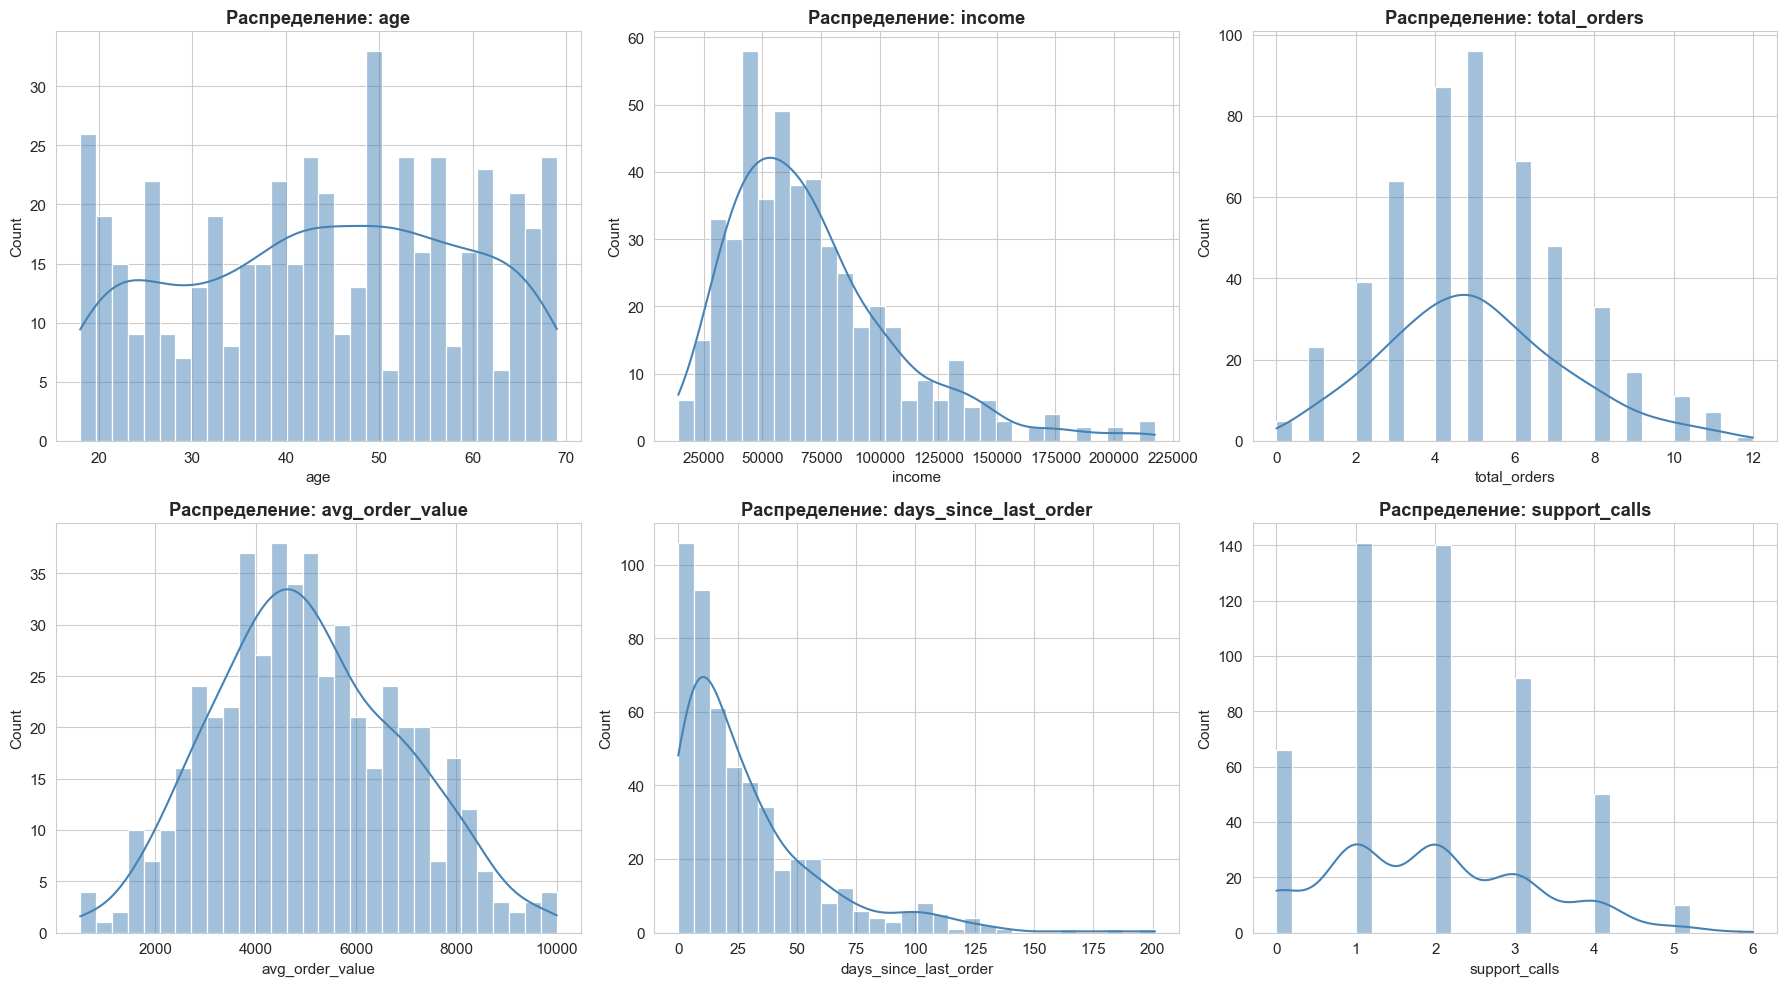

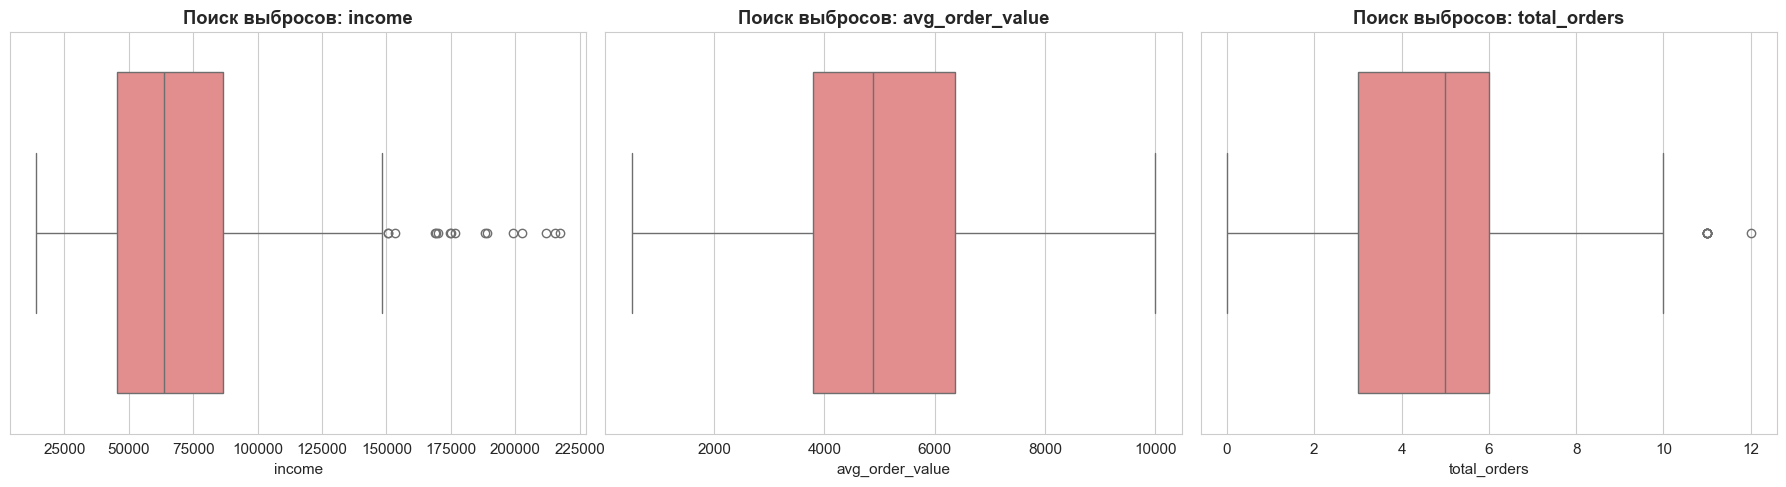


💡 Инсайты из распределений:
   • age — равномерное: клиенты всех возрастов (широкая аудитория)
   • income — логнормальное: большинство со средним доходом, «хвост» вправо = VIP-клиенты
   • total_orders — Пуассона: типично для счётных данных, много клиентов с 0-5 заказами
   • avg_order_value — близкое к нормальному: средний чек ~5000₽, отклонения = сегменты
   • days_since_last_order — экспоненциальное: пик недавних покупок, длинный хвост = «уснувшие»
   • support_calls — Пуассона: большинство 0-2 звонка, 5+ = проблемные клиенты



In [23]:
# Распределение числовых признаков
numeric_cols = ['age', 'income', 'total_orders', 'avg_order_value', 'days_since_last_order', 'support_calls']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=data, x=col, kde=True, ax=axes[idx], color='steelblue', bins=30)
    axes[idx].set_title(f'Распределение: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# Boxplots для поиска выбросов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
outlier_cols = ['income', 'avg_order_value', 'total_orders']

for idx, col in enumerate(outlier_cols):
    sns.boxplot(data=data, x=col, ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Поиск выбросов: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

print('''\n💡 Инсайты из распределений:
   • age — равномерное: клиенты всех возрастов (широкая аудитория)
   • income — логнормальное: большинство со средним доходом, «хвост» вправо = VIP-клиенты
   • total_orders — Пуассона: типично для счётных данных, много клиентов с 0-5 заказами
   • avg_order_value — близкое к нормальному: средний чек ~5000₽, отклонения = сегменты
   • days_since_last_order — экспоненциальное: пик недавних покупок, длинный хвост = «уснувшие»
   • support_calls — Пуассона: большинство 0-2 звонка, 5+ = проблемные клиенты
''')

## 🎯 Шаг 4: Анализ целевой переменной

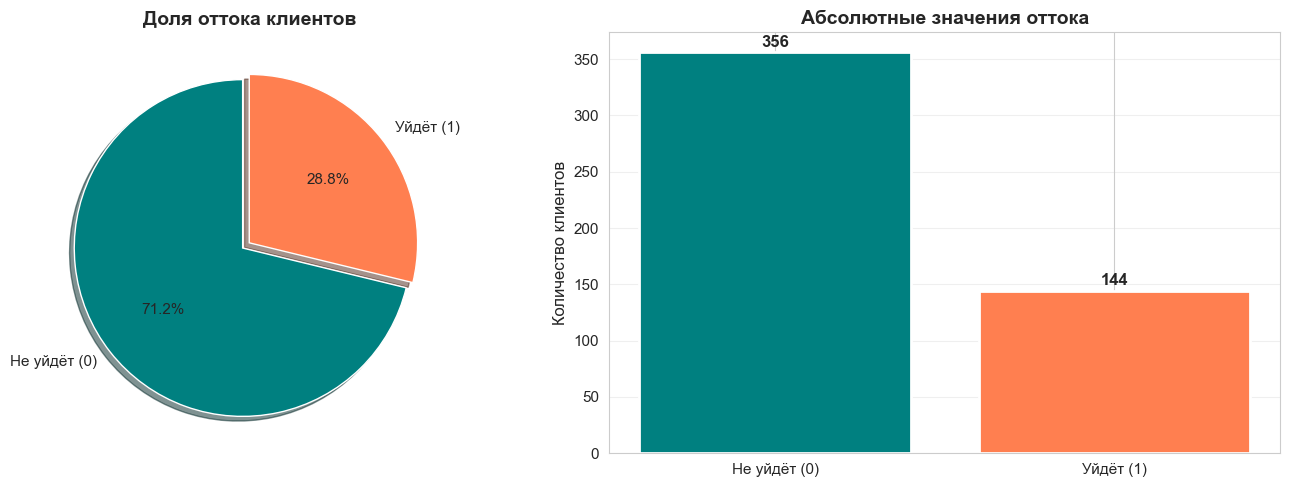


Уровень оттока (Churn Rate): 28.8%
Это значит, что каждый 3-й клиент уходит!


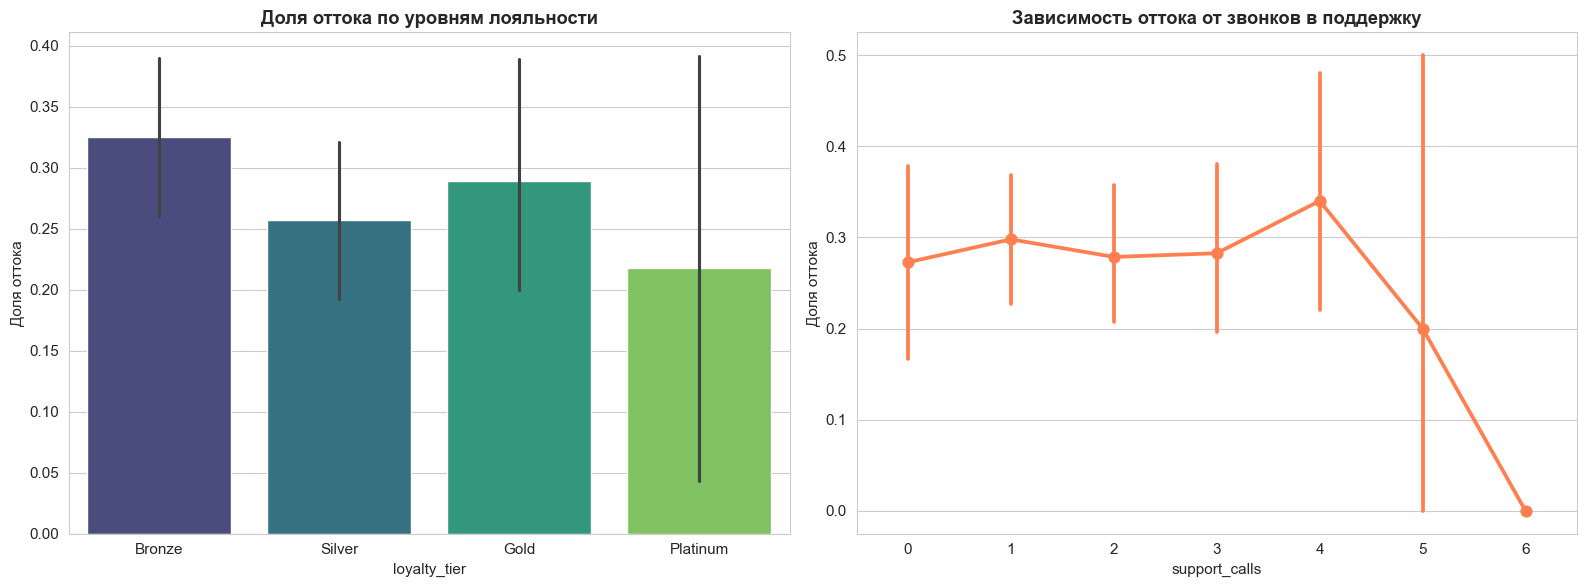

In [24]:
# Распределение churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = data['churn'].value_counts()
colors = ['teal', 'coral']
axes[0].pie(churn_counts.values, labels=['Не уйдёт (0)', 'Уйдёт (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0), shadow=True)
axes[0].set_title('Доля оттока клиентов', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Не уйдёт (0)', 'Уйдёт (1)'], churn_counts.values, 
                   color=colors, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Количество клиентов', fontsize=12)
axes[1].set_title('Абсолютные значения оттока', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, count in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

churn_rate = churn_counts.get(1, 0) / len(data) * 100
print(f'\nУровень оттока (Churn Rate): {churn_rate:.1f}%')
print(f'Это значит, что каждый {int(100/churn_rate)}-й клиент уходит!')

# Анализ оттока по категориям
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Отток по уровням лояльности
sns.barplot(data=data, x='loyalty_tier', y='churn', ax=axes[0], hue='loyalty_tier', 
            palette='viridis', order=['Bronze', 'Silver', 'Gold', 'Platinum'], legend=False)
axes[0].set_title('Доля оттока по уровням лояльности', fontweight='bold')
axes[0].set_ylabel('Доля оттока')

# Отток по количеству звонков в поддержку
sns.pointplot(data=data, x='support_calls', y='churn', ax=axes[1], color='coral')
axes[1].set_title('Зависимость оттока от звонков в поддержку', fontweight='bold')
axes[1].set_ylabel('Доля оттока')

plt.tight_layout()
plt.show()

## 🔗 Шаг 5: Взаимосвязи между признаками

Корреляция показывает, насколько сильно два признака связаны друг с другом:
- **Положительная корреляция** → при росте одного признака растёт другой
- **Отрицательная корреляция** → при росте одного признака другой уменьшается
- **Нет корреляции** → признаки независимы

### 📊 Как читать корреляционную матрицу:

| Значение | Интерпретация |
|----------|---------------|
| **0.7 – 1.0** | Сильная положительная связь |
| **0.3 – 0.7** | Умеренная положительная связь |
| **-0.3 – 0.3** | Слабая связь или отсутствует |
| **-0.7 – -0.3** | Умеренная отрицательная связь |
| **-1.0 – -0.7** | Сильная отрицательная связь |

### 🔍 На что обращать внимание:

1. **Корреляция с целевой переменной (churn)** — какие признаки влияют на отток?
2. **Корреляция между признаками** — нет ли мультиколлинеарности (дублирования информации)?
3. **Неожиданные связи** — могут указать на скрытые закономерности

**Важно!** Корреляция ≠ причинно-следственная связь! Два признака могут расти вместе из-за третьего фактора.

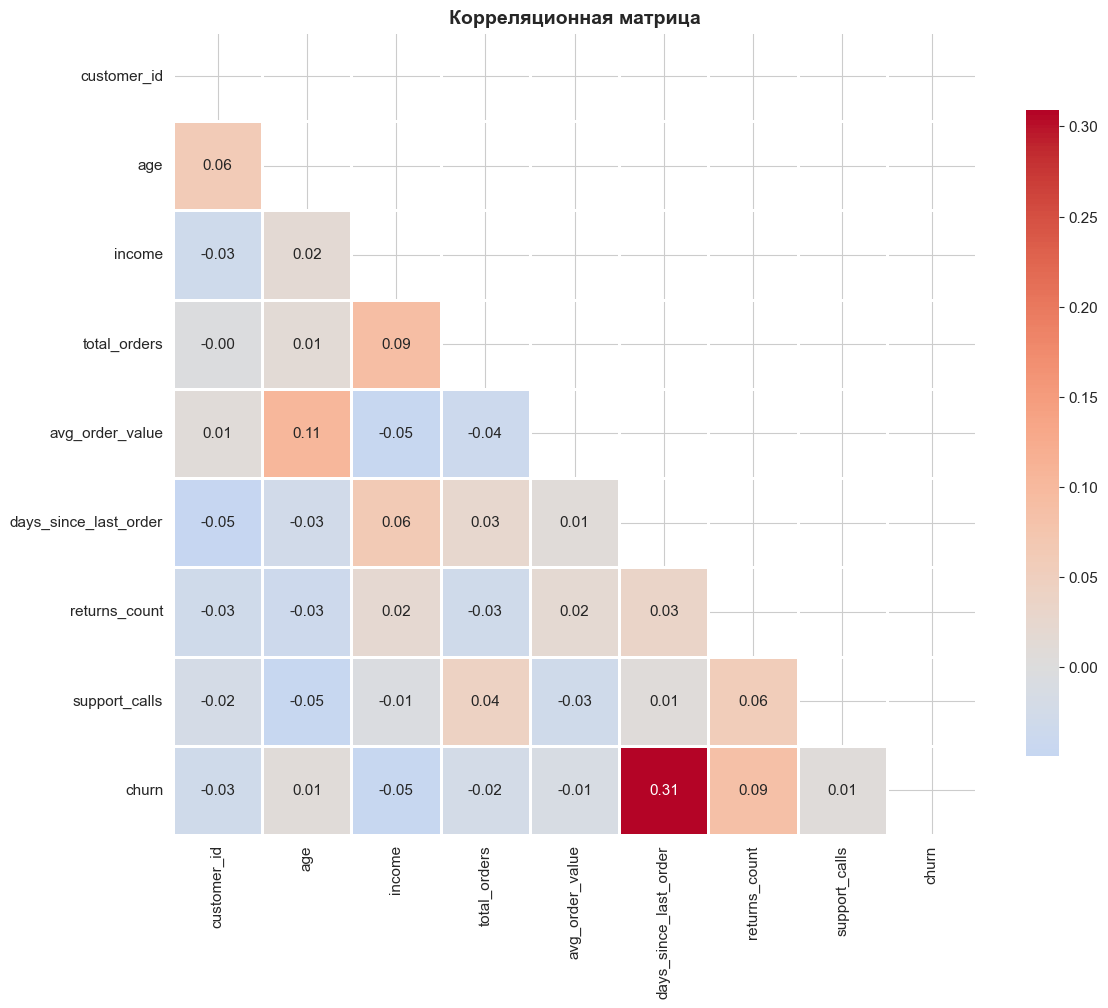


💡 Топ-5 корреляций с оттоком (churn):
   📈+ days_since_last_order: 0.309 (умеренная)
   📈+ returns_count: 0.088 (слабая)
   📉- income: -0.047 (слабая)
   📉- customer_id: -0.029 (слабая)
   📉- total_orders: -0.022 (слабая)

📌 Как интерпретировать:
   • Положительная корреляция → рост признака увеличивает отток
   • Отрицательная корреляция → рост признака уменьшает отток
   • Например: days_since_last_order имеет положительную корреляцию →
     чем дольше клиент не покупал, тем выше вероятность ухода


In [25]:
# Корреляционная матрица
numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим топ корреляций с churn
print('\n💡 Топ-5 корреляций с оттоком (churn):')
churn_correlations = corr_matrix['churn'].sort_values(ascending=False)
# Берем 5 самых сильных по модулю, исключая саму себя
top_correlations = churn_correlations.abs().sort_values(ascending=False)[1:6]

for feature in top_correlations.index:
    corr = churn_correlations[feature]
    direction = '📈+' if corr > 0 else '📉-'
    strength = 'сильная' if abs(corr) > 0.7 else 'умеренная' if abs(corr) > 0.3 else 'слабая'
    print(f'   {direction} {feature}: {corr:.3f} ({strength})')

print('\n📌 Как интерпретировать:')
print('   • Положительная корреляция → рост признака увеличивает отток')
print('   • Отрицательная корреляция → рост признака уменьшает отток')
print('   • Например: days_since_last_order имеет положительную корреляцию →')
print('     чем дольше клиент не покупал, тем выше вероятность ухода')

## 📝 Ключевые выводы

✅ EDA помогает понять структуру данных  
✅ Визуализация делает инсайты очевидными  
✅ Пропуски и выбросы нужно обрабатывать  
✅ Корреляции показывают важные взаимосвязи  

---

## ➡️ Что дальше?

В следующем уроке научимся **предобрабатывать данные**: работать с пропусками, выбросами и дубликатами.